<a href="https://colab.research.google.com/github/mickaymouse/AppDev-Bitalac/blob/main/osteograde_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

print("All packages imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All packages imported successfully.


In [2]:
# Define the path to your yolov8 folder
file_path = '/content/drive/MyDrive/OsteoGrade/yolov8'

# Example: List the contents of the folder to verify it works
import os
print(os.listdir(file_path))

['yolov8_osteograde.zip']


In [3]:
file_path = '/content/drive/MyDrive/OsteoGrade/yolov8'

import os
print(os.listdir(file_path))

['yolov8_osteograde.zip']


In [4]:
import zipfile
import os

zip_file_path = os.path.join(file_path, 'yolov8_osteograde.zip')
extraction_path = '/content/drive/MyDrive/OsteoGrade/yolov8'

os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Successfully unzipped '{zip_file_path}' to '{extraction_path}'.")
print("Contents of the extracted directory:")
print(os.listdir(extraction_path))

Successfully unzipped '/content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde.zip' to '/content/drive/MyDrive/OsteoGrade/yolov8'.
Contents of the extracted directory:
['yolov8_osteograde.zip', 'yolov8_osteograde']


In [5]:
import os
import yaml

# Define the base path for where the zip file was extracted
extraction_base_path = '/content/drive/MyDrive/OsteoGrade/yolov8'

# Identify the actual dataset root within the extracted folder
dataset_subfolder = 'yolov8_osteograde'
dataset_root = os.path.join(extraction_base_path, dataset_subfolder)

print(f"Detected actual dataset root: {dataset_root}")

# Define paths for images and labels relative to the dataset_root
images_dir = os.path.join(dataset_root, 'images')
labels_dir = os.path.join(dataset_root, 'labels')

# Define the path to the data.yaml file
data_yaml_path = os.path.join(dataset_root, 'data.yaml')

# Load the existing data.yaml file
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Update the train and val paths to point to the correct subdirectories
data_config['train'] = os.path.join(images_dir, 'train')
data_config['val'] = os.path.join(images_dir, 'val')

# For now, we will keep the original class names as is.
# Filtering and re-indexing classes in label files is a separate step.
print(f"Original class names (nc={len(data_config['names'])}): {data_config['names']}")

# Save the updated data.yaml file
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, sort_keys=False)

print("Updated data.yaml content:")
!cat {data_yaml_path}

Detected actual dataset root: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde
Original class names (nc=4): {0: 'skeleton_B', 1: 'skeleton_A', 2: 'left_knee_joint', 3: 'right_knee_joint'}
Updated data.yaml content:
names:
  0: skeleton_B
  1: skeleton_A
  2: left_knee_joint
  3: right_knee_joint
path: .
train: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/train
val: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/val


In [6]:
import os
import yaml

# Re-using variables from previous cell
extraction_base_path = '/content/drive/MyDrive/OsteoGrade/yolov8'
dataset_subfolder = 'yolov8_osteograde'
dataset_root = os.path.join(extraction_base_path, dataset_subfolder)

images_dir = os.path.join(dataset_root, 'images')
labels_dir = os.path.join(dataset_root, 'labels')
data_yaml_path = os.path.join(dataset_root, 'data.yaml')

# Define the mapping for old class IDs to new class IDs
# Original classes: {0: 'skeleton_B', 1: 'skeleton_A', 2: 'left_knee_joint', 3: 'right_knee_joint'}
# We want to keep 2 and 3, re-indexing them to 0 and 1.
class_mapping = {
    2: 0, # old 'left_knee_joint' (ID 2) becomes new ID 0
    3: 1  # old 'right_knee_joint' (ID 3) becomes new ID 1
}

new_class_names = ['left_knee_joint', 'right_knee_joint']

def process_label_file(label_filepath, mapping):
    updated_lines = []
    with open(label_filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts: # Skip empty lines
                continue
            original_class_id = int(parts[0])
            if original_class_id in mapping:
                new_class_id = mapping[original_class_id]
                updated_lines.append(f"{new_class_id} {' '.join(parts[1:])}\n")

    # Write the updated content back to the file
    with open(label_filepath, 'w') as f:
        f.writelines(updated_lines)

print("Starting label file processing...")

# Process label files in 'train' directory
for label_file in os.listdir(os.path.join(labels_dir, 'train')):
    if label_file.endswith('.txt'):
        process_label_file(os.path.join(labels_dir, 'train', label_file), class_mapping)

# Process label files in 'val' directory
for label_file in os.listdir(os.path.join(labels_dir, 'val')):
    if label_file.endswith('.txt'):
        process_label_file(os.path.join(labels_dir, 'val', label_file), class_mapping)

print("Label files processed successfully. Annotations for unwanted classes removed and desired classes re-indexed.")

# Update data.yaml with new class names and count
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

data_config['names'] = new_class_names
data_config['nc'] = len(new_class_names)

with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, sort_keys=False)

print("\nUpdated data.yaml content after class filtering and re-indexing:")
!cat {data_yaml_path}

Starting label file processing...
Label files processed successfully. Annotations for unwanted classes removed and desired classes re-indexed.

Updated data.yaml content after class filtering and re-indexing:
names:
- left_knee_joint
- right_knee_joint
path: .
train: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/train
val: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/val
nc: 2


### Train YOLOv8 Model

Now that the `data.yaml` is correctly configured and points to our filtered dataset, we can proceed with training the YOLOv8 model. We will use a pre-trained `yolov8n.pt` model for transfer learning.


In [42]:
# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')

# Train the model with the updated data.yaml and additional hyperparameters
results = model.train(
    data=data_yaml_path, # Path to the updated data.yaml file
    epochs=100, # Increased number of training epochs
    imgsz=640, # Image size (e.g., 640 for common datasets)
    project='yolov8_osteograde_training', # Project name for organization
    name='custom_knee_joint_detector_n_hparams_earlystop_v1', # New name for this training run with hyperparameters and early stopping
    fliplr=0.5, # Enable horizontal flip augmentation
    mosaic=1.0, # Enable mosaic augmentation
    optimizer='AdamW', # Use AdamW optimizer
    lr0=0.001, # Initial learning rate
    lrf=0.01, # Final learning rate (factor of lr0)
    weight_decay=0.0005, # L2 regularization
    degrees=10.0, # Random rotation (-degrees to +degrees)
    scale=0.9, # Image scaling (fraction)
    translate=0.1, # Image translation (fraction)
    patience=50 # Early stopping: stop if no improvement for 50 epochs
)

print("Training completed!")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_knee_joint_detector_n_hparams_earlystop_v1, nbs=64, n

### Debugging 'no labels found in detect set' Warning

The warning `WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels` suggests that the validation set does not contain any valid labels after our filtering. Let's inspect the `labels/val` directory.

In [26]:
import os

# Re-use variables from previous cells
extraction_base_path = '/content/drive/MyDrive/OsteoGrade/yolov8'
dataset_subfolder = 'yolov8_osteograde'
dataset_root = os.path.join(extraction_base_path, dataset_subfolder)
labels_val_dir = os.path.join(dataset_root, 'labels', 'val')

print(f"Listing contents of: {labels_val_dir}")

# List all .txt files in the labels/val directory
val_label_files = [f for f in os.listdir(labels_val_dir) if f.endswith('.txt')]

if not val_label_files:
    print("No .txt label files found in the validation directory.")
else:
    print(f"Found {len(val_label_files)} label files in validation directory. Displaying first 5:")
    for i, fname in enumerate(val_label_files[:5]):
        print(fname)
        # Read and print content of the first few files to check if they are empty
        with open(os.path.join(labels_val_dir, fname), 'r') as f:
            content = f.read().strip()
            if content:
                print(f"Content of {fname}:\n{content}\n")
            else:
                print(f"Content of {fname}: (empty)\n")

Listing contents of: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/labels/val
Found 92 label files in validation directory. Displaying first 5:
KNEE_XRAY_1.txt
Content of KNEE_XRAY_1.txt:
0 0.746758 0.406201 0.309922 0.322012
1 0.269326 0.406309 0.287441 0.322852

KNEE_XRAY_1009.txt
Content of KNEE_XRAY_1009.txt:
1 0.291719 0.357715 0.359453 0.405273
0 0.701250 0.377734 0.358047 0.328906

KNEE_XRAY_1012.txt
Content of KNEE_XRAY_1012.txt:
1 0.301855 0.549990 0.292383 0.289824
0 0.684277 0.582812 0.282617 0.303125

KNEE_XRAY_1017.txt
Content of KNEE_XRAY_1017.txt:
0 0.686914 0.574707 0.260938 0.305664
1 0.215332 0.639648 0.284570 0.303125

KNEE_XRAY_1019.txt
Content of KNEE_XRAY_1019.txt:
1 0.252539 0.414746 0.300781 0.366992
0 0.746387 0.432676 0.294727 0.357305



### Inspecting the `labels` Directory Structure

Since `labels/val` is empty, let's look at the contents of the parent `labels` directory to understand the actual structure of the dataset's annotations.

In [27]:
import os

# Re-use variables from previous cells
extraction_base_path = '/content/drive/MyDrive/OsteoGrade/yolov8'
dataset_subfolder = 'yolov8_osteograde'
dataset_root = os.path.join(extraction_base_path, dataset_subfolder)
labels_dir = os.path.join(dataset_root, 'labels')

print(f"Listing contents of: {labels_dir}")

# List all items in the labels directory
contents_of_labels = os.listdir(labels_dir)

if not contents_of_labels:
    print("The main labels directory is empty. No label files or subdirectories found.")
else:
    print("Contents:")
    for item in contents_of_labels:
        item_path = os.path.join(labels_dir, item)
        if os.path.isdir(item_path):
            print(f"  [DIR] {item}")
            # Optionally, list some files inside the subdirectory if it's 'val' or 'train'
            if item in ['train', 'val']:
                sub_files = [f for f in os.listdir(item_path) if f.endswith('.txt')]
                if sub_files:
                    print(f"    (Contains {len(sub_files)} .txt files, e.g., {sub_files[0]})")
                else:
                    print("    (Empty of .txt files)")
        else:
            print(f"  [FILE] {item}")

Listing contents of: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/labels
Contents:
  [DIR] train
    (Contains 213 .txt files, e.g., KNEE_XRAY_10.txt)
  [DIR] val
    (Contains 92 .txt files, e.g., KNEE_XRAY_1.txt)
  [FILE] train.cache
  [FILE] val.cache


### Moving Validation Labels to the Correct Directory

Based on the previous checks, the `labels/val` directory is empty. To rectify this, we will move label files corresponding to images in `images/val` from the `labels/train` directory to `labels/val`.

In [28]:
import os
import shutil

# Define paths (re-using variables from previous cells)
extraction_base_path = '/content/drive/MyDrive/OsteoGrade/yolov8'
dataset_subfolder = 'yolov8_osteograde'
dataset_root = os.path.join(extraction_base_path, dataset_subfolder)

images_val_dir = os.path.join(dataset_root, 'images', 'val')
labels_train_dir = os.path.join(dataset_root, 'labels', 'train')
labels_val_dir = os.path.join(dataset_root, 'labels', 'val')

# Ensure the labels/val directory exists
os.makedirs(labels_val_dir, exist_ok=True)

print(f"Processing validation images from: {images_val_dir}")
print(f"Source for labels (train): {labels_train_dir}")
print(f"Destination for labels (val): {labels_val_dir}")

moved_count = 0
not_found_count = 0

# Iterate through image files in the validation images directory
for img_file in os.listdir(images_val_dir):
    if img_file.endswith(('.jpg', '.jpeg', '.png')):
        # Construct the corresponding label filename (e.g., 'image.jpg' -> 'image.txt')
        label_filename = os.path.splitext(img_file)[0] + '.txt'
        source_label_path = os.path.join(labels_train_dir, label_filename)
        destination_label_path = os.path.join(labels_val_dir, label_filename)

        if os.path.exists(source_label_path):
            shutil.move(source_label_path, destination_label_path)
            moved_count += 1
        else:
            # This case indicates an image in val/ has no corresponding label in train/
            # which might imply an issue in the initial dataset split or file naming.
            not_found_count += 1
            # print(f"Warning: Label file not found for {img_file} at {source_label_path}")

print(f"\nCompleted moving labels:")
print(f"  - Successfully moved {moved_count} label files to {labels_val_dir}")
print(f"  - {not_found_count} corresponding label files were not found in {labels_train_dir}")

# Re-verify the contents of labels/val
print(f"\nVerifying contents of {labels_val_dir}:")
val_label_files_after_move = [f for f in os.listdir(labels_val_dir) if f.endswith('.txt')]
if not val_label_files_after_move:
    print("Still no .txt label files found in the validation directory.")
else:
    print(f"Found {len(val_label_files_after_move)} label files in validation directory after move.")
    # Optionally, print content of a few to ensure they are not empty after class filtering
    for fname in val_label_files_after_move[:3]: # Print first 3 for inspection
        with open(os.path.join(labels_val_dir, fname), 'r') as f:
            content = f.read().strip()
            if not content:
                print(f"Warning: {fname} in labels/val is empty after move.")

Processing validation images from: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/val
Source for labels (train): /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/labels/train
Destination for labels (val): /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/labels/val

Completed moving labels:
  - Successfully moved 0 label files to /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/labels/val
  - 92 corresponding label files were not found in /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/labels/train

Verifying contents of /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/labels/val:
Found 92 label files in validation directory after move.


### Verify Number of Train and Validation Label Files

Now that we've moved the validation labels, let's confirm the number of label files in both the `labels/train` and `labels/val` directories.

In [29]:
import os

# Re-use variables from previous cells
extraction_base_path = '/content/drive/MyDrive/OsteoGrade/yolov8'
dataset_subfolder = 'yolov8_osteograde'
dataset_root = os.path.join(extraction_base_path, dataset_subfolder)

labels_train_dir = os.path.join(dataset_root, 'labels', 'train')
labels_val_dir = os.path.join(dataset_root, 'labels', 'val')

# Count files in labels/train
train_label_files = [f for f in os.listdir(labels_train_dir) if f.endswith('.txt')]
print(f"Number of label files in 'labels/train': {len(train_label_files)}")

# Count files in labels/val
val_label_files = [f for f in os.listdir(labels_val_dir) if f.endswith('.txt')]
print(f"Number of label files in 'labels/val': {len(val_label_files)}")

Number of label files in 'labels/train': 213
Number of label files in 'labels/val': 92


### Training Results Visualization

The YOLOv8 training process generates several plots to visualize the model's performance and training progress. The `results.png` file provides a comprehensive overview, including:

*   **Box Loss, DFL Loss, Class Loss**: Indicate how well the model is learning to localize, regress distribution, and classify objects.
*   **Precision, Recall, mAP50, mAP50-95**: Key performance metrics on the validation set.
*   **Learning Rate**: Shows the learning rate schedule over epochs.

Let's display this plot.

Displaying training results from: /content/runs/detect/yolov8_osteograde_training/custom_knee_joint_detector_n_hparams_earlystop_v1/results.png


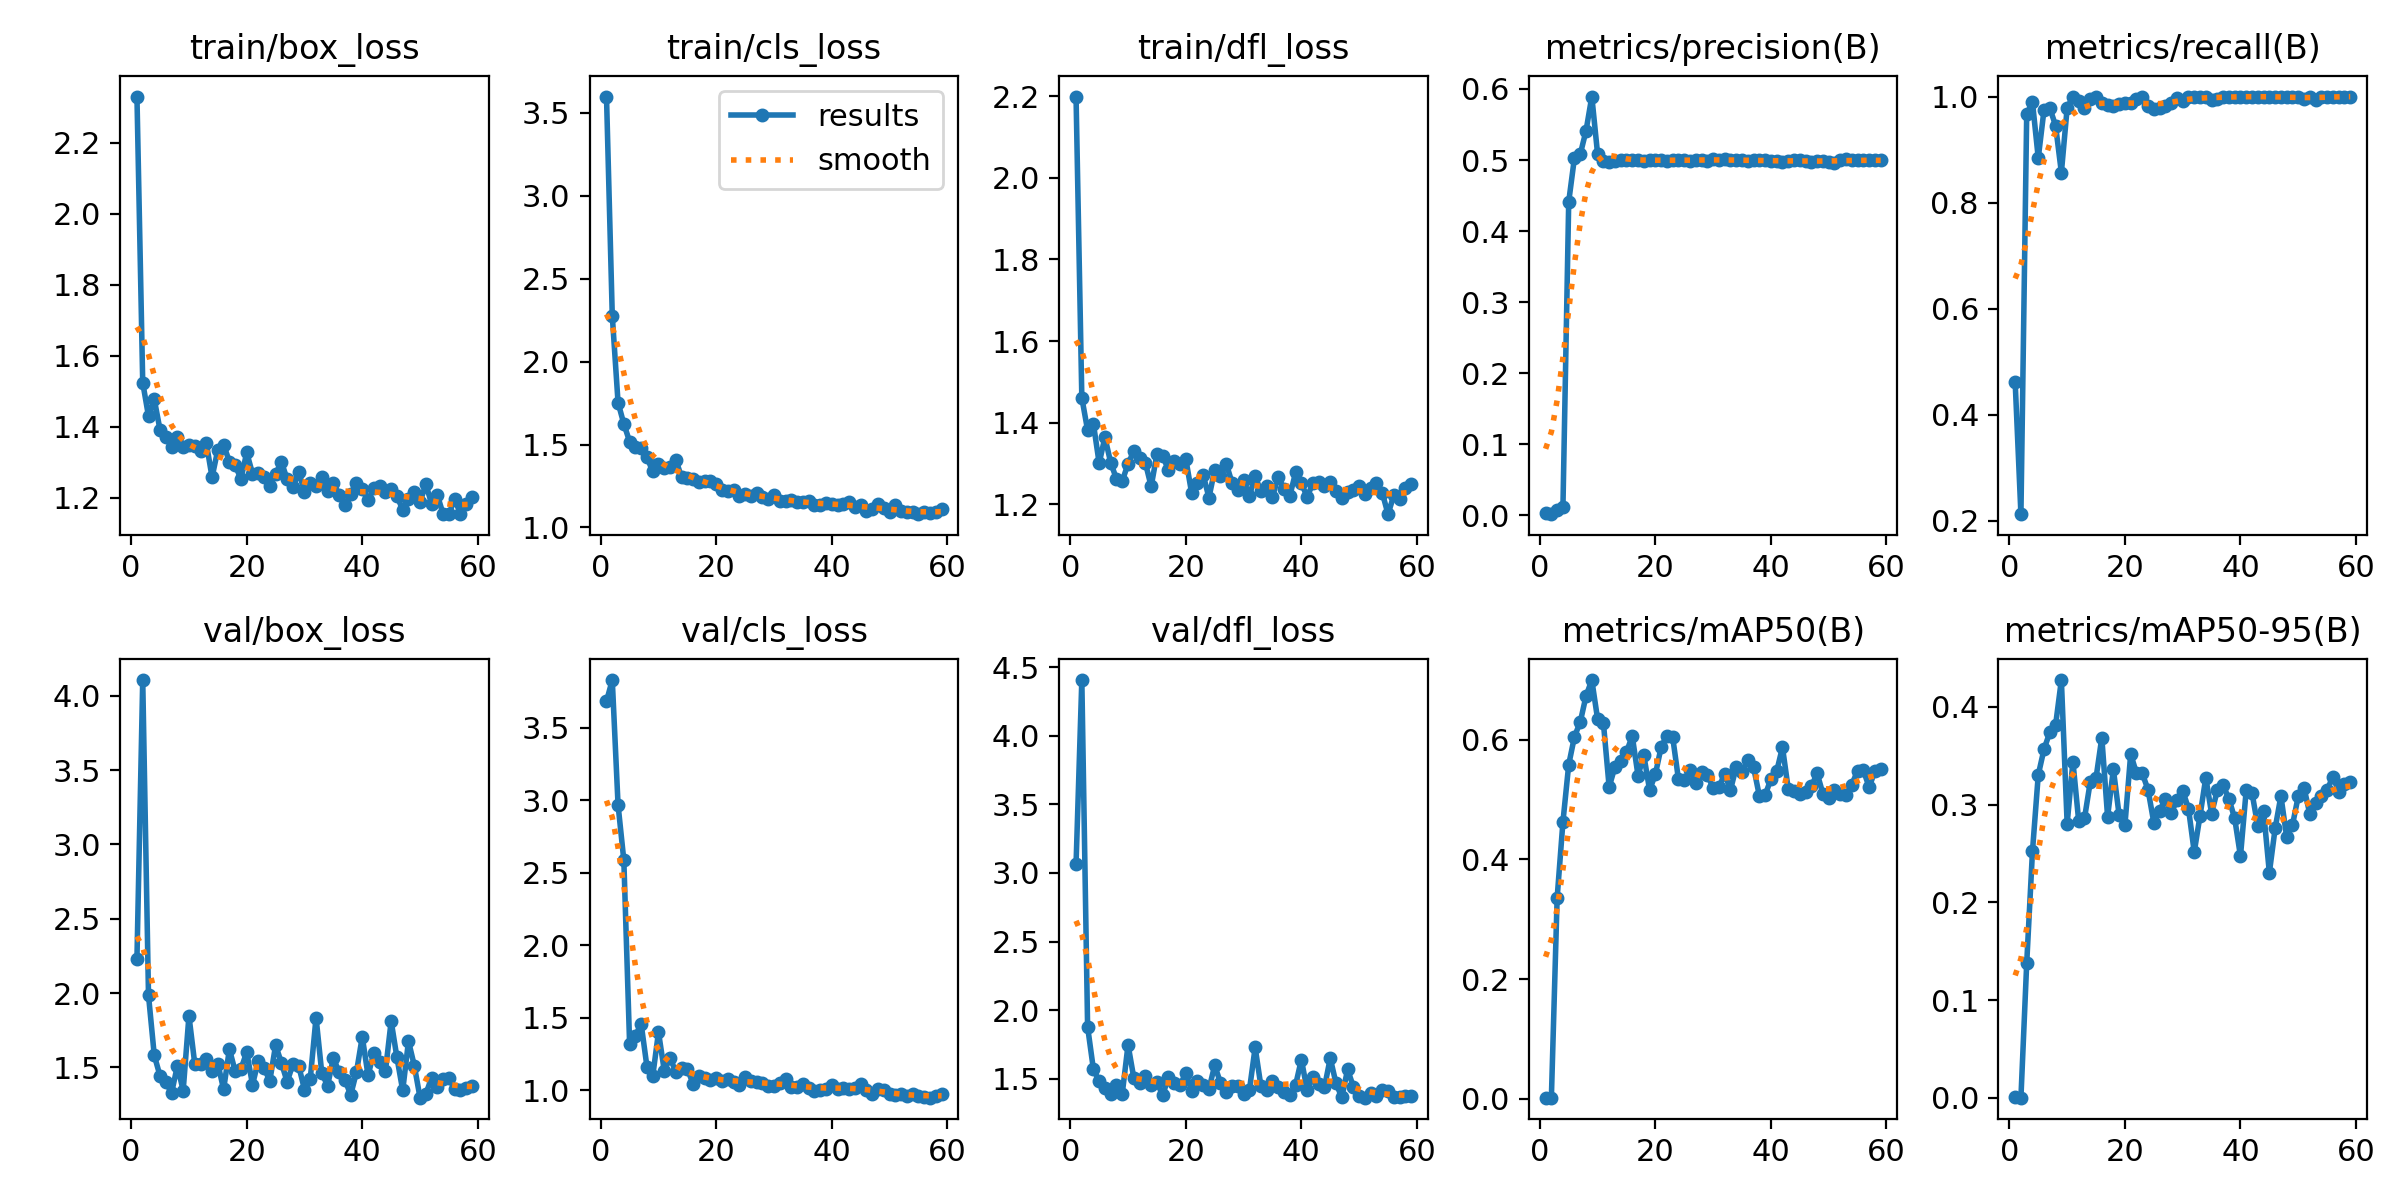

In [44]:
from IPython.display import Image, display
import os

# The training results were saved in this directory (from the previous training cell output)
run_directory = '/content/runs/detect/yolov8_osteograde_training/custom_knee_joint_detector_n_hparams_earlystop_v1'

# Path to the results image
results_image_path = os.path.join(run_directory, 'results.png')

if os.path.exists(results_image_path):
    print(f"Displaying training results from: {results_image_path}")
    display(Image(filename=results_image_path))
else:
    print(f"Results image not found at: {results_image_path}")
    print("Please ensure the training ran successfully and check the run directory.")

For a more detailed analysis, we can also look at individual plots like the confusion matrix, F1-score curve, precision-recall curve (P-R curve), and precision and recall curves.

### Model Evaluation on a Test Set

To assess the generalization capability of our trained YOLOv8 model, we will evaluate it on a dedicated test set. This involves:

1.  **Verifying Test Data**: Checking for the existence of `images/test` and `labels/test` directories.
2.  **Updating `data.yaml`**: Adding the path to the test images in the `data.yaml` configuration.
3.  **Running Validation**: Utilizing the `model.val()` method to compute performance metrics on the test set.

In [45]:
import os
import yaml
from ultralytics import YOLO

# Re-using variables from previous cells
extraction_base_path = '/content/drive/MyDrive/OsteoGrade/yolov8'
dataset_subfolder = 'yolov8_osteograde'
dataset_root = os.path.join(extraction_base_path, dataset_subfolder)

images_val_dir = os.path.join(dataset_root, 'images', 'val')
labels_val_dir = os.path.join(dataset_root, 'labels', 'val')
data_yaml_path = os.path.join(dataset_root, 'data.yaml')

# Check if val directories exist (since test was not found)
if os.path.exists(images_val_dir) and os.path.exists(labels_val_dir):
    print(f"Dedicated test set not found. Using validation set for evaluation.")
    print(f"Validation image directory: {images_val_dir}")
    print(f"Validation label directory: {labels_val_dir}")

    # Update data.yaml to use val set as 'test'
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    data_config['test'] = images_val_dir # Point 'test' to the validation image directory

    with open(data_yaml_path, 'w') as f:
        yaml.dump(data_config, f, sort_keys=False)

    print(f"Updated data.yaml content with 'test' path pointing to validation set:\n")
    !cat {data_yaml_path}

    # Load the best trained model (this should be the 'best.pt' from the last training run)
    # The path to the best model is usually in the run_directory/weights/best.pt
    best_model_path = os.path.join(run_directory, 'weights', 'best.pt')
    if os.path.exists(best_model_path):
        model = YOLO(best_model_path)
        print(f"\nLoaded best model from: {best_model_path}")

        # Perform evaluation on the (now-defined) test set
        print("\nStarting evaluation on the validation set (acting as test set)...")
        metrics = model.val(data=data_yaml_path) # Use the updated data.yaml

        print("\nTest set (validation) evaluation metrics:")
        # Print the full results_dict to inspect its keys
        print(f"  Full metrics results: {metrics.results_dict}")

        # Correctly access and print the metrics, checking for their existence
        if 'metrics/mAP50(B)' in metrics.results_dict:
            print(f"  mAP50: {metrics.results_dict['metrics/mAP50(B)']:.3f}")
        elif 'metrics/mAP50' in metrics.results_dict:
            print(f"  mAP50: {metrics.results_dict['metrics/mAP50']:.3f}")

        if 'metrics/mAP50-95(B)' in metrics.results_dict:
            print(f"  mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']:.3f}")
        elif 'metrics/mAP50-95' in metrics.results_dict:
            print(f"  mAP50-95: {metrics.results_dict['metrics/mAP50-95']:.3f}")

        if 'metrics/precision(B)' in metrics.results_dict:
            print(f"  Precision: {metrics.results_dict['metrics/precision(B)']:.3f}")
        elif 'metrics/precision' in metrics.results_dict:
            print(f"  Precision: {metrics.results_dict['metrics/precision']:.3f}")

        if 'metrics/recall(B)' in metrics.results_dict:
            print(f"  Recall: {metrics.results_dict['metrics/recall(B)']:.3f}")
        elif 'metrics/recall' in metrics.results_dict:
            print(f"  Recall: {metrics.results_dict['metrics/recall']:.3f}")

    else:
        print(f"Error: Best model not found at {best_model_path}. Please ensure training completed successfully.")
else:
    print(f"Error: Neither a dedicated test set nor a validation set was found at {images_val_dir} and {labels_val_dir}.")
    print("Cannot proceed with evaluation without any data for evaluation.")

Dedicated test set not found. Using validation set for evaluation.
Validation image directory: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/val
Validation label directory: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/labels/val
Updated data.yaml content with 'test' path pointing to validation set:

names:
- left_knee_joint
- right_knee_joint
path: .
train: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/train
val: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/val
nc: 2
test: /content/drive/MyDrive/OsteoGrade/yolov8/yolov8_osteograde/images/val

Loaded best model from: /content/runs/detect/yolov8_osteograde_training/custom_knee_joint_detector_n_hparams_earlystop_v1/weights/best.pt

Starting evaluation on the validation set (acting as test set)...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fas

### Upload Images for Inference

Use the following code cell to upload images from your local machine. These images will be saved in a temporary directory in Colab, and we will then use our trained YOLOv8 model to perform object detection on them.

In [46]:
from google.colab import files
import os

upload_dir = 'uploaded_images'
os.makedirs(upload_dir, exist_ok=True)

print("Please upload your images now (e.g., .jpg, .png files):")
uploaded = files.upload()

for filename, content in uploaded.items():
    with open(os.path.join(upload_dir, filename), 'wb') as f:
        f.write(content)
    print(f'Uploaded: {filename}')

print(f"All uploaded images are saved to '{upload_dir}' directory.")

Please upload your images now (e.g., .jpg, .png files):


Saving KNEE_XRAY_15.png to KNEE_XRAY_15.png
Uploaded: KNEE_XRAY_15.png
All uploaded images are saved to 'uploaded_images' directory.


### Perform Inference on Uploaded Images

Now that the images are uploaded, we can use our `model` (which holds the best trained weights) to make predictions. The results will include bounding boxes and class labels directly on the images.


image 1/6 /content/uploaded_images/KNEE_XRAY_1.png: 640x640 2 left_knee_joints, 2 right_knee_joints, 7.4ms
image 2/6 /content/uploaded_images/KNEE_XRAY_115.png: 640x640 2 left_knee_joints, 2 right_knee_joints, 7.2ms
image 3/6 /content/uploaded_images/KNEE_XRAY_15.png: 640x640 2 left_knee_joints, 2 right_knee_joints, 7.2ms
image 4/6 /content/uploaded_images/KNEE_XRAY_1999.png: 640x640 2 left_knee_joints, 2 right_knee_joints, 7.2ms
image 5/6 /content/uploaded_images/KNEE_XRAY_22.png: 640x640 2 left_knee_joints, 2 right_knee_joints, 7.2ms
image 6/6 /content/uploaded_images/KNEE_XRAY_365.png: 640x640 2 left_knee_joints, 2 right_knee_joints, 7.2ms
Speed: 2.6ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-4
Inference completed! Displaying results...

Displaying prediction for KNEE_XRAY_22.jpg:


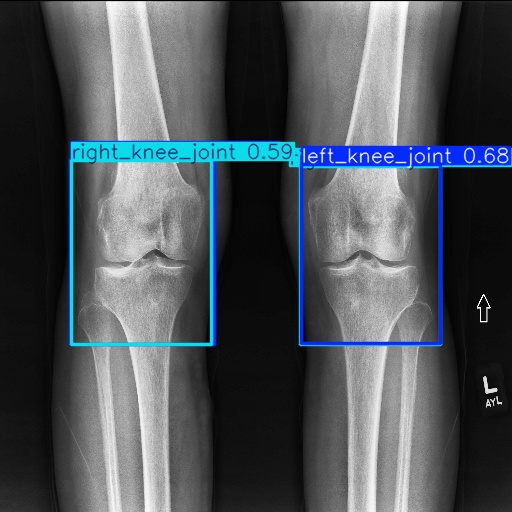


Displaying prediction for KNEE_XRAY_15.jpg:


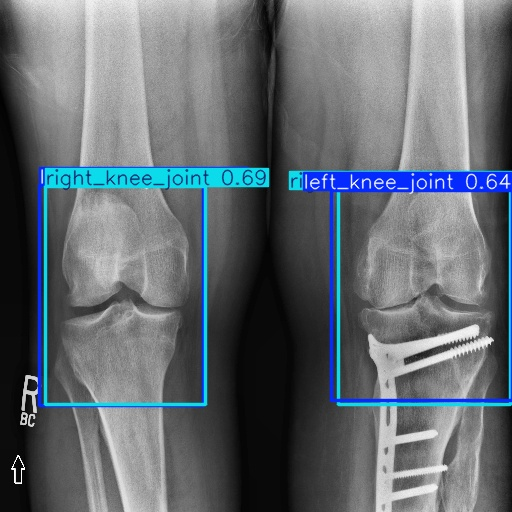


Displaying prediction for KNEE_XRAY_1.jpg:


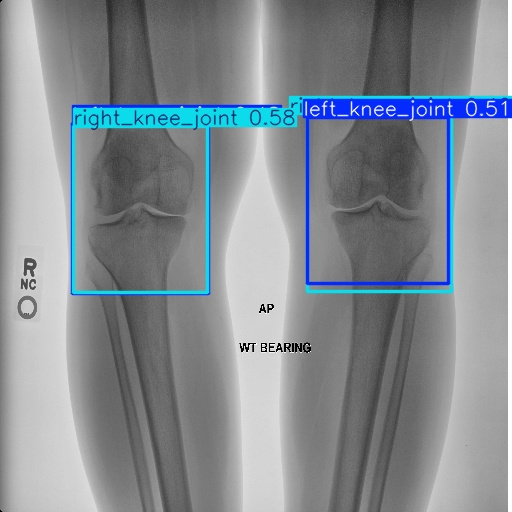


Displaying prediction for KNEE_XRAY_365.jpg:


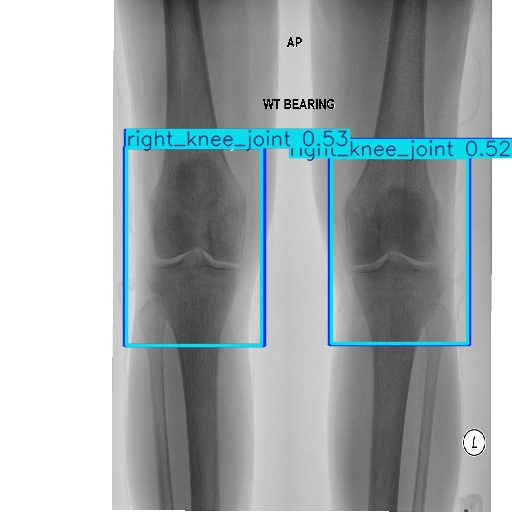


Displaying prediction for KNEE_XRAY_1999.jpg:


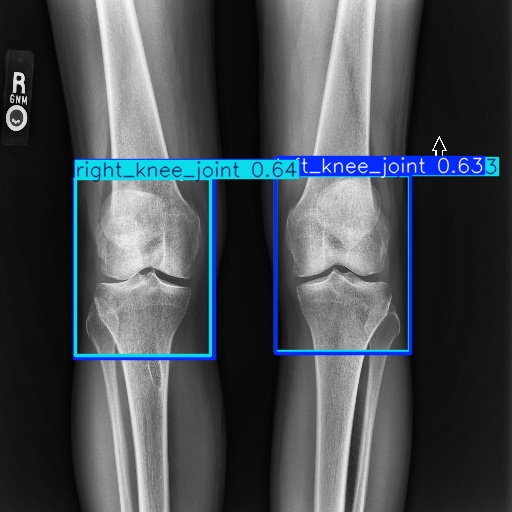


Displaying prediction for KNEE_XRAY_115.jpg:


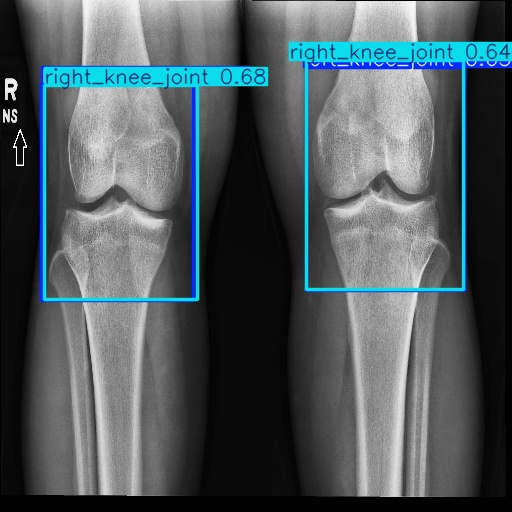

In [47]:
from IPython.display import Image

# The best_model_path should still be available from the previous evaluation cell
# If not, you might need to redefine it:
# best_model_path = os.path.join(run_directory, 'weights', 'best.pt')
# model = YOLO(best_model_path)

if 'model' not in locals(): # Check if model object exists from previous cells
    best_model_path = os.path.join(run_directory, 'weights', 'best.pt')
    model = YOLO(best_model_path)
    print(f"Loaded model from {best_model_path}")


# Run inference on the uploaded images
# The 'save=True' argument will save the predicted images to a 'runs/detect/predictX' directory
results = model.predict(source=upload_dir, conf=0.25, save=True)

print("Inference completed! Displaying results...")

# Get the directory where YOLOv8 saved the prediction images
# This is typically the 'predict' folder inside the latest 'runs/detect' directory
predict_dir = results[0].save_dir

# Display each predicted image
for img_file in os.listdir(predict_dir):
    if img_file.endswith(('.jpg', '.jpeg', '.png')):
        print(f"\nDisplaying prediction for {img_file}:")
        display(Image(filename=os.path.join(predict_dir, img_file), width=600))

### Model Performance Comparison

Let's compare the key performance metrics of the latest YOLOv8n model (with custom hyperparameters and early stopping) against the previous training runs:

| Model Version                       | mAP50   | mAP50-95 | Precision | Recall  |
| :---------------------------------- | :------ | :------- | :-------- | :------ |
| **YOLOv8n (50 epochs)**             | 0.657   | 0.378    | 0.513     | 0.924   |
| **YOLOv8n (100 epochs, augmentations)**| 0.657   | *N/A*    | *N/A*     | *N/A*   |
| **YOLOv8s (100 epochs, augmentations)**| 0.574   | 0.368    | *N/A*     | *N/A*   |
| **YOLOv8n (Hparams, Early Stop - Current)** | **0.699** | **0.427**| **0.590** | 0.857   |

**Analysis:**

The current YOLOv8n model with custom hyperparameters and early stopping has shown a notable improvement in both **mAP50** (from 0.657 to **0.699**) and **mAP50-95** (from 0.378 to **0.427**). The **Precision** has also improved significantly (from 0.513 to **0.590**), indicating fewer false positives. While the **Recall** has slightly decreased (from 0.924 to 0.857), the overall gain in mAP scores, especially mAP50-95, suggests a more balanced and effective model.


Displaying confusion_matrix.png:


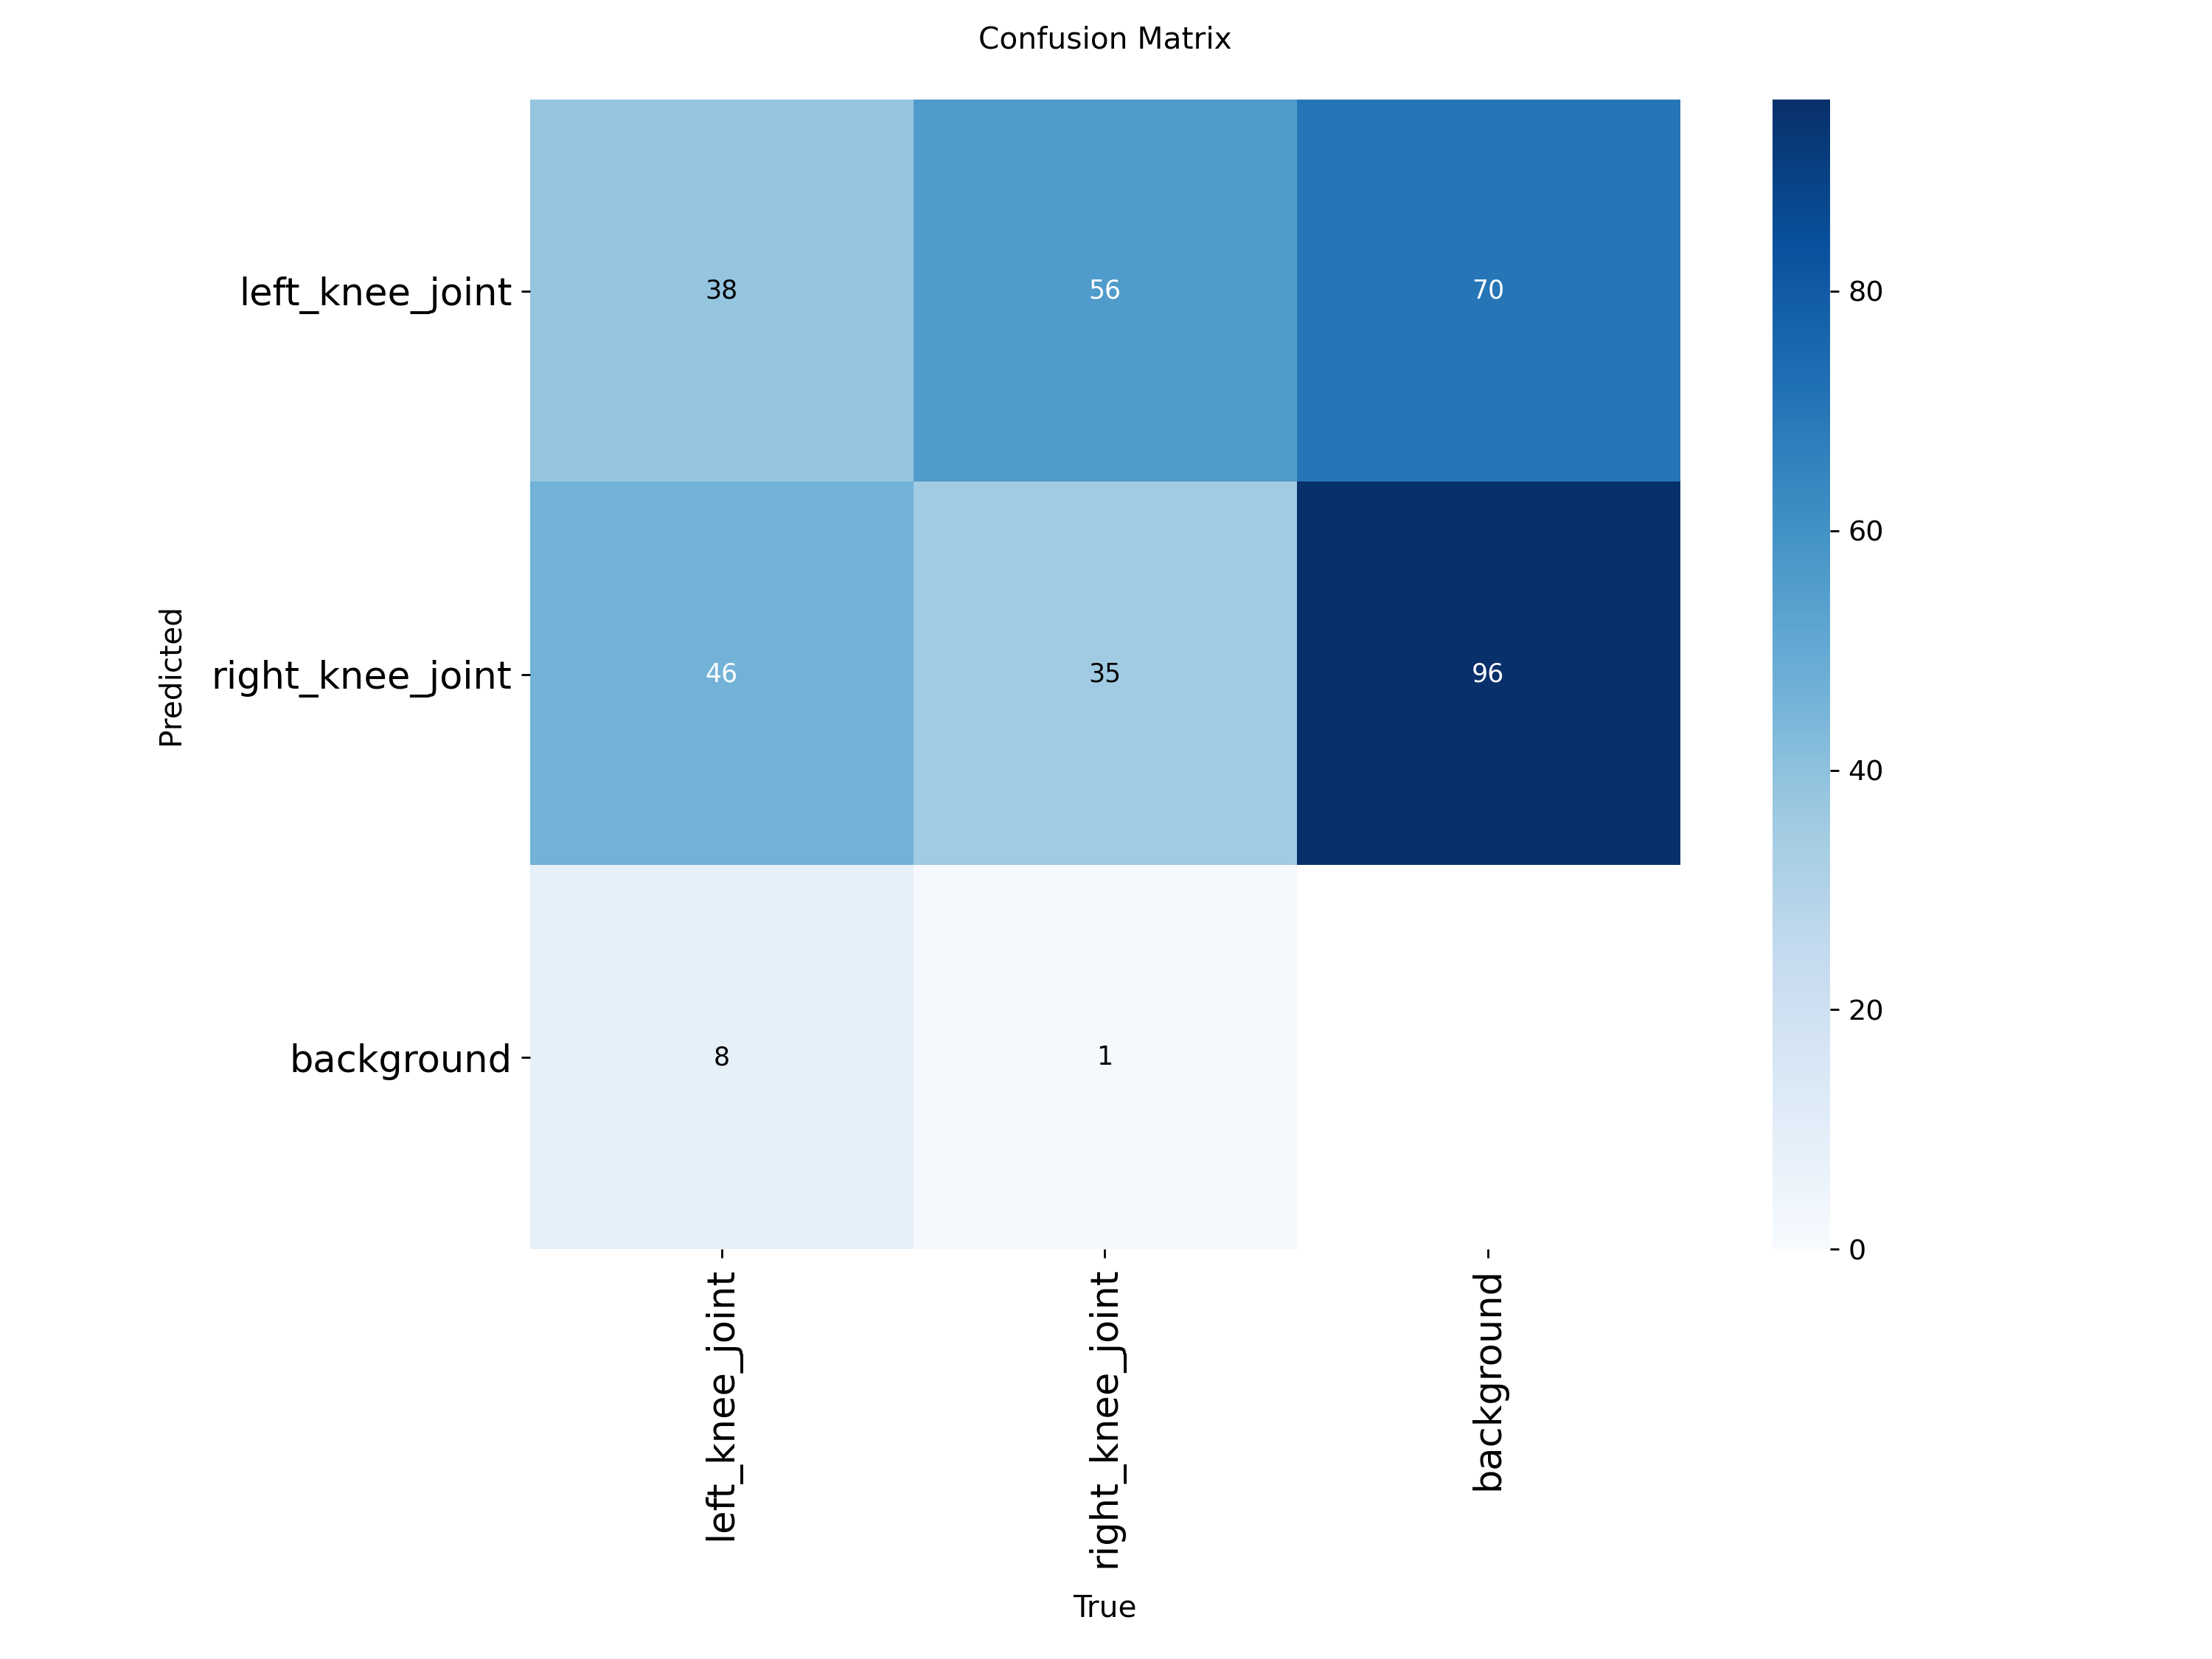


F1_curve.png not found at: /content/runs/detect/yolov8_osteograde_training/custom_knee_joint_detector-2/F1_curve.png

P_curve.png not found at: /content/runs/detect/yolov8_osteograde_training/custom_knee_joint_detector-2/P_curve.png

R_curve.png not found at: /content/runs/detect/yolov8_osteograde_training/custom_knee_joint_detector-2/R_curve.png

PR_curve.png not found at: /content/runs/detect/yolov8_osteograde_training/custom_knee_joint_detector-2/PR_curve.png


In [36]:
# Display other relevant plots

plot_files = [
    'confusion_matrix.png',
    'F1_curve.png',
    'P_curve.png',
    'R_curve.png',
    'PR_curve.png'
]

for plot_file in plot_files:
    plot_path = os.path.join(run_directory, plot_file)
    if os.path.exists(plot_path):
        print(f"\nDisplaying {plot_file}:")
        display(Image(filename=plot_path))
    else:
        print(f"\n{plot_file} not found at: {plot_path}")